,Toplam_Tutar_TL,Percentage
Departman,,
MUTFAK (F&B),1.223227e+09,36.06
TEKNİK SERVİS,6.946902e+08,20.48
KAT HİZMETLERİ,5.510314e+08,16.24
OFİS,5.077123e+08,14.97
BAR/REST.,4.159731e+08,12.26


,Toplam_Tutar_TL,Percentage
Tedarikci,,
Saray Kasabı,7.138415e+08,21.04
Pepsi Dağıtım,7.025756e+08,20.71
Global Gıda,6.765719e+08,19.94
Ofis Dünyası,6.654384e+08,19.61
Teknik Market,6.342069e+08,18.69


,Toplam_Tutar_TL,CumSum,CumPercentage
Urun_Adi,,,
ŞAMPUAN,1.328625e+08,1.328625e+08,3.92
ZIMBA,1.251842e+08,2.580467e+08,7.61
BALIK,1.173596e+08,3.754063e+08,11.07
BAKLİYAT,1.103772e+08,4.857835e+08,14.32
HELVA,1.103014e+08,5.960849e+08,17.57
AMPUL,1.081033e+08,7.041882e+08,20.76
KLİMA GAZI,1.072857e+08,8.114738e+08,23.92
KÖMÜR,1.049117e+08,9.163855e+08,27.01
KALEM,1.042746e+08,1.020660e+09,30.08


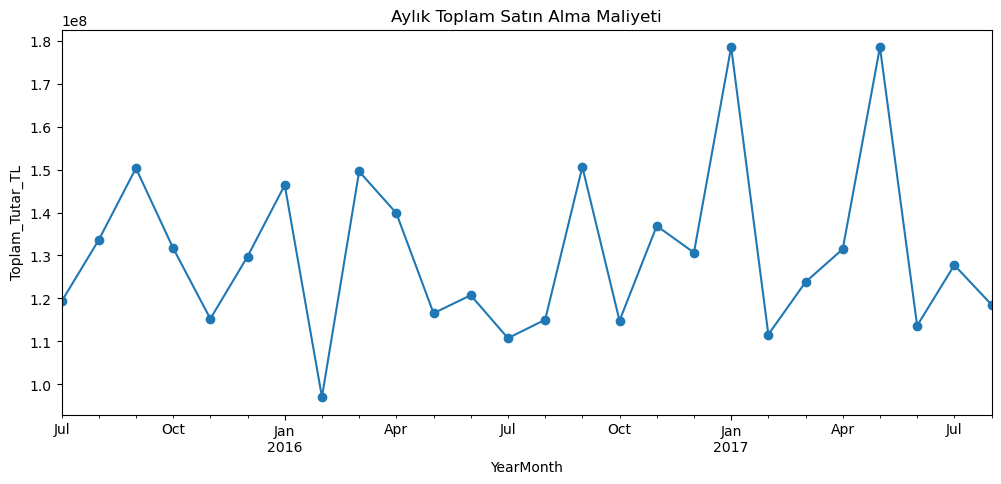

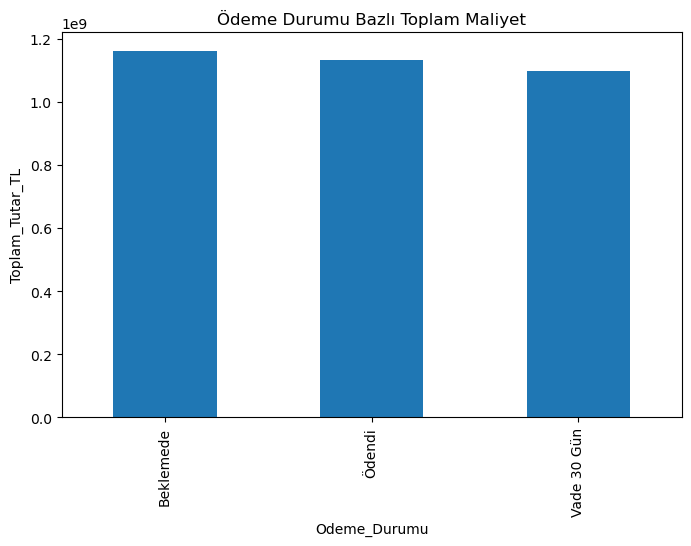

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dosya yolu (EXCEL)
file_path = r"C:\Users\DeLL\Downloads\Otel_Operasyon_Master.xlsx"

# Sheet yükleme
df_satin_alma = pd.read_excel(file_path, sheet_name="3_Satin_Alma_Maliyet")

# Tarih kolonunu datetime yap
df_satin_alma['Islem_Tarihi'] = pd.to_datetime(df_satin_alma['Islem_Tarihi'])
df_satin_alma['YearMonth'] = df_satin_alma['Islem_Tarihi'].dt.to_period('M')

## Departman Bazlı Maliyet

departman_total = df_satin_alma.groupby('Departman')['Toplam_Tutar_TL'].sum().sort_values(ascending=False)
departman_total_pct = (departman_total / departman_total.sum() * 100).round(2)
departman_summary = pd.DataFrame({'Toplam_Tutar_TL': departman_total, 'Percentage': departman_total_pct})
display(departman_summary)

## Tedarikçi Bazlı Maliyet

tedarikci_total = df_satin_alma.groupby('Tedarikci')['Toplam_Tutar_TL'].sum().sort_values(ascending=False)
tedarikci_total_pct = (tedarikci_total / tedarikci_total.sum() * 100).round(2)
tedarikci_summary = pd.DataFrame({'Toplam_Tutar_TL': tedarikci_total, 'Percentage': tedarikci_total_pct})
display(tedarikci_summary)

## Ürün Pareto Analizi

urun_total = df_satin_alma.groupby('Urun_Adi')['Toplam_Tutar_TL'].sum().sort_values(ascending=False)
urun_cumsum = urun_total.cumsum()
urun_cum_pct = (urun_cumsum / urun_total.sum() * 100).round(2)
urun_pareto = pd.DataFrame({'Toplam_Tutar_TL': urun_total, 'CumSum': urun_cumsum, 'CumPercentage': urun_cum_pct})
display(urun_pareto.head(20))

## Aylık Trend Analizi

monthly_total = df_satin_alma.groupby('YearMonth')['Toplam_Tutar_TL'].sum()
monthly_total.plot(kind='line', figsize=(12,5), marker='o', title='Aylık Toplam Satın Alma Maliyeti')
plt.ylabel('Toplam_Tutar_TL')
plt.show()

## Ödeme Durumu Analizi

odeme_summary = df_satin_alma.groupby('Odeme_Durumu')['Toplam_Tutar_TL'].sum().sort_values(ascending=False)
odeme_summary.plot(kind='bar', figsize=(8,5), title='Ödeme Durumu Bazlı Toplam Maliyet')
plt.ylabel('Toplam_Tutar_TL')
plt.show()